<a href="https://colab.research.google.com/github/ZoryAce/Topicos/blob/main/ENTREGA3/TALLER2/T2_PatentCitationNetwork3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Patent Citation Network

U.S. patent dataset is maintained by the [National Bureau of Economic Research](http://www.nber.org/). The data set spans 37 years (January 1, 1963 to December 30, 1999), and includes all the utility patents granted during that period, totaling 3,923,922 patents. The citation graph includes all citations made by patents granted between 1975 and 1999, totaling 16,522,438 citations. For the patents dataset there are 1,803,511 nodes for which we have no information about their citations (we only have the in-links).

The data was originally released by [NBER](http://www.nber.org/patents/). The dataset can be found at this link: [Stanford Patent Citation Network](https://snap.stanford.edu/data/cit-Patents.html)

In [1]:
!pip install numpy==1.26.4

## Import Packages

In [2]:
!pip install node2vec

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 16.5 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.


In [3]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from random import randint

%matplotlib inline

from node2vec import Node2Vec
import seaborn as sns
from sklearn.decomposition import PCA

## Import data

In [4]:
patent = pd.read_csv(
    "http://snap.stanford.edu/data/cit-Patents.txt.gz",
    compression="gzip",
    sep="\t",
    names=["start_node", "end_node"],
    skiprows=5
)

In [5]:
patent.head()

,start_node,end_node
0,3858241,1324234
1,3858241,3398406
2,3858241,3557384
3,3858241,3634889
4,3858242,1515701


In [6]:
patent.shape

(16518947, 2)

In [7]:
patent=patent[:1000]

## Build Recommendation System

build a recommendation system based on Node2Vec with the patent information, remember to do a descriptive analysis and apply visualizations.

Also, remember that when making a recommendation about which patent should be associated with another, make a visualization of the recommendation.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   start_node  1000 non-null   int64
 1   end_node    1000 non-null   int64
dtypes: int64(2)
memory usage: 15.8 KB
None
         start_node      end_node
count  1.000000e+03  1.000000e+03
mean   3.858342e+06  2.842753e+06
std    5.788760e+01  8.135533e+05
min    3.858241e+06  1.404000e+04
25%    3.858290e+06  2.392961e+06
50%    3.858345e+06  3.076836e+06
75%    3.858392e+06  3.470756e+06
max    3.858440e+06  3.822586e+06
   start_node  end_node
0     3858241   1324234
1     3858241   3398406
2     3858241   3557384
3     3858241   3634889
4     3858242   1515701
start_node    0
end_node      0
dtype: int64


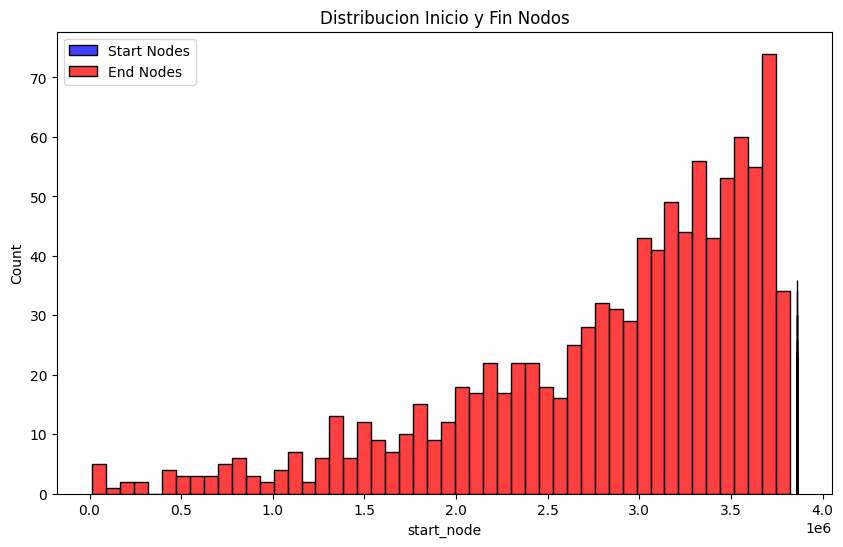

In [8]:
# Descriptive analysis
print(patent.info())
print(patent.describe())
print(patent.head())
print(patent.isnull().sum())

plt.figure(figsize=(10, 6))
sns.histplot(patent['start_node'], kde=False, bins=50, color='blue', label='Start Nodes')
sns.histplot(patent['end_node'], kde=False, bins=50, color='red', label='End Nodes')
plt.title('Distribucion Inicio y Fin Nodos')
plt.legend()
plt.show()

In [9]:
G = nx.from_pandas_edgelist(patent, 'start_node', 'end_node')
print("Numero de Nodos:", G.number_of_nodes())
print("Numero de Aristas:", G.number_of_edges())
print("Densidad Grafo:", nx.density(G))
print("Dirigido:", G.is_directed())
print("Conectado:", nx.is_connected(G) if not G.is_directed() else "N/A for directed graphs")

# Entrenamiento modelo Node2vec
node2vec = Node2Vec(G, dimensions=64, walk_length=30, num_walks=200, workers=1)
model = node2vec.fit(window=10, min_count=1, batch_words=4)
model.wv.save_word2vec_format('patent_embeddings.emb')

Numero de Nodos: 1196
Numero de Aristas: 1000
Densidad Grafo: 0.0013993646884314522
Dirigido: False
Conectado: False


Computing transition probabilities:   0%|          | 0/1196 [00:00<?, ?it/s]

Generating walks (CPU: 1): 100%|██████████| 200/200 [00:30<00:00,  6.62it/s]


Recomendaciones por patente 3858241: [3557384, 1324234, 3634889, 3398406, 2130311]


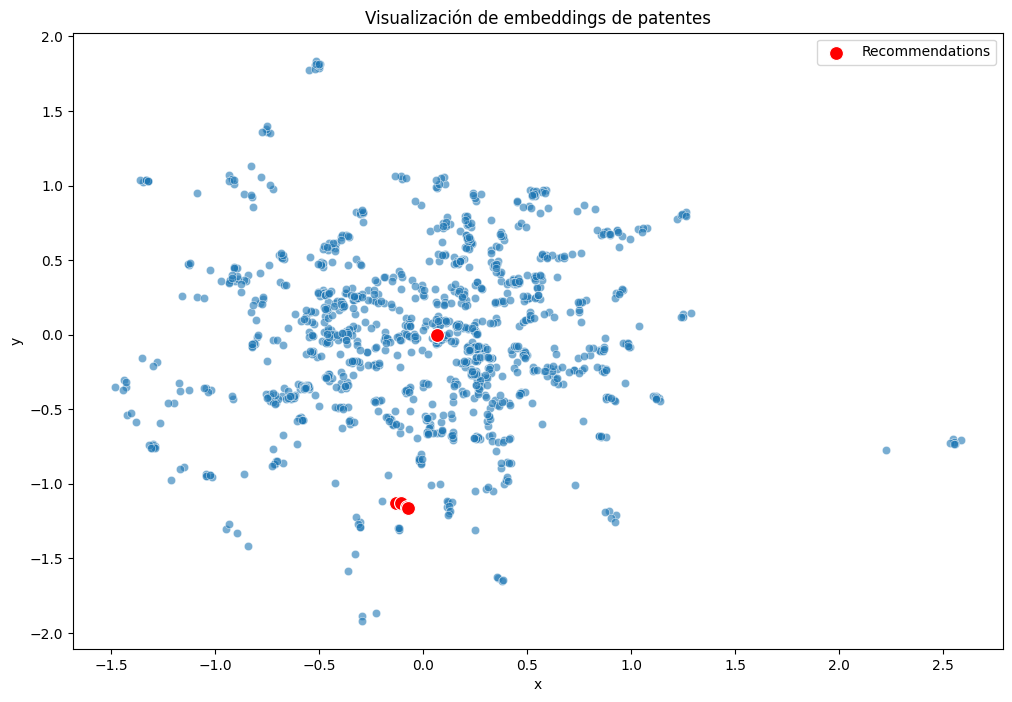

In [10]:
# Función Recomendaciones
def get_recommendations(node, top_n=5):
    try:
        similar_nodes = model.wv.most_similar(str(node), topn=top_n)
        return [int(node[0]) for node in similar_nodes]
    except KeyError:
        return []

# Tomamos un numero de ejemplo de patente
patent_id = 3858241
recommendations = get_recommendations(patent_id)
print(f"Recomendaciones por patente {patent_id}: {recommendations}")


embeddings = model.wv.vectors
nodes = model.wv.index_to_key
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

# Visualización
df_embeddings = pd.DataFrame(embeddings_2d, columns=['x', 'y'])
df_embeddings['node'] = nodes

# Graficar embeddings
plt.figure(figsize=(12, 8))
sns.scatterplot(x='x', y='y', data=df_embeddings, alpha=0.6)

if recommendations:
    rec_indices = [nodes.index(str(node)) for node in recommendations if str(node) in nodes]
    sns.scatterplot(x=df_embeddings.loc[rec_indices, 'x'], y=df_embeddings.loc[rec_indices, 'y'], color='red', s=100, label='Recommendations')

plt.title('Visualización de embeddings de patentes')
plt.legend()
plt.show()
